In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("khoongweihao/covid19-xray-dataset-train-test-sets")

print("Path to dataset files:", path)

/home/youngwon/anaconda3/envs/analysis/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 84.3M/84.3M [00:09<00:00, 9.73MB/s]

Extracting files...


Path to dataset files: /home/youngwon/.cache/kagglehub/datasets/khoongweihao/covid19-xray-dataset-train-test-sets/versions/1


In [2]:
import numpy as np 
import pandas as pd 

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [3]:
import tensorflow as tf
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import pandas as pd

I0000 00:00:1778070043.155942    5231 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778070044.416351    5231 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778070049.871625    5231 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


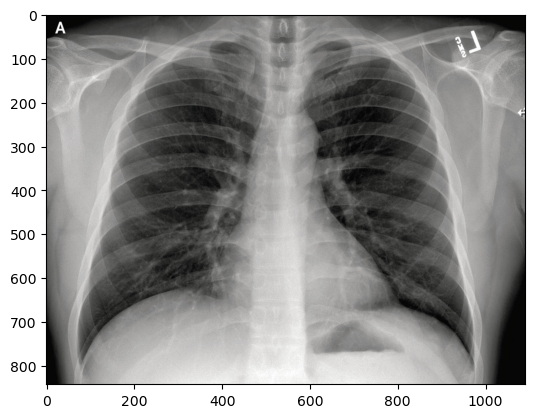

In [4]:
plt.imshow(cv2.imread(os.path.join(path, "xray_dataset_covid19/train/PNEUMONIA/nejmoa2001191_f1-PA.jpeg")))

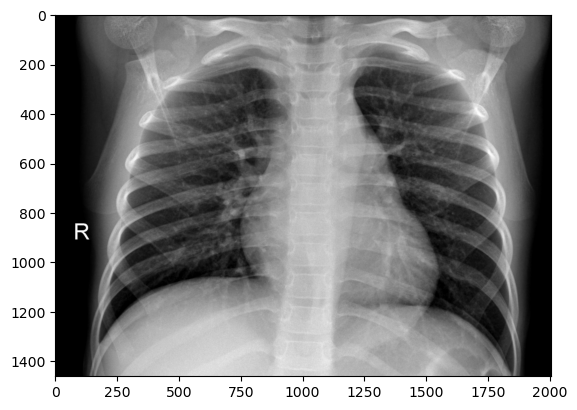

In [5]:
plt.imshow(cv2.imread(os.path.join(path, "xray_dataset_covid19/train/NORMAL/IM-0086-0001.jpeg")))

## 1. 데이터셋 구조 확인 및 로드

먼저 Kagglehub를 통해 다운로드된 X-ray 데이터셋의 폴더 구조를 확인하고, TensorFlow의 `ImageDataGenerator`를 사용하여 이미지를 로드하고 전처리할 준비를 합니다. 데이터는 `train`과 `test` 폴더로 나누어져 있으며, 각 폴더 안에는 `NORMAL`과 `PNEUMONIA` (COVID-19 포함) 클래스 폴더가 있습니다.

In [6]:
import os

# 데이터셋 기본 경로 설정
dataset_path = os.path.join(path, "xray_dataset_covid19")

print("Contents of dataset_path:")
for item in os.listdir(dataset_path):
    print(os.path.join(dataset_path, item))

# train 및 test 디렉토리 경로 정의
train_dir = os.path.join(dataset_path, 'train')
test_dir = os.path.join(dataset_path, 'test')

print(f"\nTrain directory: {train_dir}")
print(f"Test directory: {test_dir}")

print("\nContents of train_dir:")
for item in os.listdir(train_dir):
    print(os.path.join(train_dir, item))

print("\nContents of test_dir:")
for item in os.listdir(test_dir):
    print(os.path.join(test_dir, item))

Contents of dataset_path:
/home/youngwon/.cache/kagglehub/datasets/khoongweihao/covid19-xray-dataset-train-test-sets/versions/1/xray_dataset_covid19/test
/home/youngwon/.cache/kagglehub/datasets/khoongweihao/covid19-xray-dataset-train-test-sets/versions/1/xray_dataset_covid19/train

Train directory: /home/youngwon/.cache/kagglehub/datasets/khoongweihao/covid19-xray-dataset-train-test-sets/versions/1/xray_dataset_covid19/train
Test directory: /home/youngwon/.cache/kagglehub/datasets/khoongweihao/covid19-xray-dataset-train-test-sets/versions/1/xray_dataset_covid19/test

Contents of train_dir:
/home/youngwon/.cache/kagglehub/datasets/khoongweihao/covid19-xray-dataset-train-test-sets/versions/1/xray_dataset_covid19/train/NORMAL
/home/youngwon/.cache/kagglehub/datasets/khoongweihao/covid19-xray-dataset-train-test-sets/versions/1/xray_dataset_covid19/train/PNEUMONIA

Contents of test_dir:
/home/youngwon/.cache/kagglehub/datasets/khoongweihao/covid19-xray-dataset-train-test-sets/versions/1/xr

## 2. 데이터 전처리 및 증강

`ImageDataGenerator`를 사용하여 학습 데이터에 증강(Augmentation)을 적용하여 모델의 일반화 성능을 향상시키고, 검증(validation) 및 테스트 데이터는 스케일링만 진행합니다. 학습 데이터를 80%는 학습용으로, 20%는 검증용으로 분리합니다.

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 이미지 크기 및 배치 크기 설정
IMG_WIDTH, IMG_HEIGHT = 224, 224 # MobileNetV2에 적합한 크기
BATCH_SIZE = 32

# 학습 데이터용 ImageDataGenerator (데이터 증강 및 스케일링)
train_datagen = ImageDataGenerator(
    rescale=1./255, # 이미지 픽셀 값 0-1로 스케일링
    rotation_range=20, # 20도 내에서 랜덤 회전
    width_shift_range=0.2, # 가로 20% 내에서 랜덤 이동
    height_shift_range=0.2, # 세로 20% 내에서 랜덤 이동
    shear_range=0.2, # 전단 변환
    zoom_range=0.2, # 20% 내에서 랜덤 확대/축소
    horizontal_flip=True, # 랜덤 수평 뒤집기
    fill_mode='nearest', # 채워지지 않은 픽셀을 가장 가까운 픽셀로 채움
    validation_split=0.2 # 학습 데이터의 20%를 검증 데이터로 사용
)

# 테스트 데이터용 ImageDataGenerator (스케일링만 진행, 증강 없음)
test_datagen = ImageDataGenerator(rescale=1./255)

# 학습 데이터 제너레이터 생성
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary', # 이진 분류 (NORMAL vs PNEUMONIA)
    subset='training' # 학습 서브셋 지정
)

# 검증 데이터 제너레이터 생성
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation' # 검증 서브셋 지정
)

# 테스트 데이터 제너레이터 생성
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False # 평가 시 데이터 순서 유지를 위해 셔플 끄기
)

Found 120 images belonging to 2 classes.
Found 28 images belonging to 2 classes.
Found 40 images belonging to 2 classes.


In [8]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

# MobileNetV2 기본 모델 로드 (ImageNet 가중치 사용, 최상단 분류 레이어 제외)
base_model = MobileNetV2(
    input_shape=(IMG_WIDTH, IMG_HEIGHT, 3), # 이미지 입력 형태
    include_top=False, # 최상단 분류 레이어 제외
    weights='imagenet' # ImageNet으로 사전 학습된 가중치 사용
)

# 기본 모델의 레이어를 동결하여 학습되지 않도록 설정
base_model.trainable = False

# 새로운 분류 레이어 추가
x = base_model.output
x = GlobalAveragePooling2D()(x) # 특징 맵을 단일 벡터로 변환
x = Dense(128, activation='relu')(x) # 128개의 뉴런을 가진 완전 연결 레이어
x = Dropout(0.5)(x) # 과적합 방지를 위한 드롭아웃
predictions = Dense(1, activation='sigmoid')(x) # 이진 분류를 위한 출력 레이어 (sigmoid 활성화 함수)

# 전체 모델 정의
model = Model(inputs=base_model.input, outputs=predictions)

# 모델 요약 출력
model.summary()

W0000 00:00:1778070165.083048    7968 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1778070168.015088    5231 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 4. 모델 컴파일 및 학습

모델 컴파일 단계에서는 최적화 함수(optimizer), 손실 함수(loss function), 그리고 평가 지표(metrics)를 정의합니다. 이진 분류 문제이므로 `Adam` 옵티마이저, `binary_crossentropy` 손실 함수, 그리고 `accuracy`, `Precision`, `Recall` 지표를 사용합니다.

모델 학습 시에는 `EarlyStopping` 콜백을 사용하여 검증 손실이 개선되지 않으면 학습을 조기에 중단하고, `ModelCheckpoint`를 사용하여 가장 좋은 성능을 보인 모델을 저장합니다.

In [9]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 모델 컴파일
model.compile(
    optimizer=Adam(learning_rate=0.0001), # 낮은 학습률로 미세 조정
    loss='binary_crossentropy', # 이진 분류를 위한 손실 함수
    metrics=['accuracy', Precision(), Recall()] # 정확도, 정밀도, 재현율 평가 지표
)

# 학습 에포크 수 설정 (데모를 위해 작은 값으로 설정)
epochs = 10

# EarlyStopping 콜백 설정: 3 에포크 동안 검증 손실이 개선되지 않으면 학습 중단
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True # 가장 좋은 성능을 보인 가중치로 복원
)

# ModelCheckpoint 콜백 설정: 가장 좋은 검증 손실을 보인 모델 저장
model_checkpoint = ModelCheckpoint(
    'best_xray_model.h5', # 저장될 모델 파일 이름
    monitor='val_loss',
    save_best_only=True # 가장 좋은 모델만 저장
)

# 모델 학습
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=validation_generator,
    callbacks=[early_stopping, model_checkpoint]
)

Epoch 1/10


I0000 00:00:1778070214.450173    5231 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5156 - loss: 0.8259 - precision: 0.5045 - recall: 0.7309

4/4 ━━━━━━━━━━━━━━━━━━━━ 26s 4s/step - accuracy: 0.5333 - loss: 0.7744 - precision: 0.5244 - recall: 0.7167 - val_accuracy: 0.6429 - val_loss: 0.5952 - val_precision: 0.6111 - val_recall: 0.7857
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6159 - loss: 0.6892 - precision: 0.5517 - recall: 0.6870

4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.6000 - loss: 0.7029 - precision: 0.6034 - recall: 0.5833 - val_accuracy: 0.8929 - val_loss: 0.5262 - val_precision: 0.9231 - val_recall: 0.8571
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.6083 - loss: 0.6502 - precision: 0.6140 - recall: 0.5833 - val_accuracy: 0.7500 - val_loss: 0.5316 - val_precision: 0.7692 - val_recall: 0.7143
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6328 - loss: 0.6373 - precision: 0.6342 - recall: 0.6385

...

4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.7500 - loss: 0.5084 - precision: 0.7206 - recall: 0.8167 - val_accuracy: 0.8571 - val_loss: 0.4647 - val_precision: 0.7778 - val_recall: 1.0000
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8103 - loss: 0.4384 - precision: 0.8160 - recall: 0.8329

4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.7833 - loss: 0.4465 - precision: 0.7742 - recall: 0.8000 - val_accuracy: 0.8929 - val_loss: 0.4624 - val_precision: 0.8235 - val_recall: 1.0000
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7819 - loss: 0.5049 - precision: 0.7720 - recall: 0.8345

4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.7833 - loss: 0.4717 - precision: 0.7656 - recall: 0.8167 - val_accuracy: 0.8929 - val_loss: 0.3689 - val_precision: 0.8667 - val_recall: 0.9286
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.7667 - loss: 0.4451 - precision: 0.7500 - recall: 0.8000 - val_accuracy: 0.8214 - val_loss: 0.3732 - val_precision: 0.8462 - val_recall: 0.7857
Epoch 9/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8267 - loss: 0.3868 - precision: 0.8448 - recall: 0.7982

4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.8500 - loss: 0.3738 - precision: 0.8750 - recall: 0.8167 - val_accuracy: 0.9286 - val_loss: 0.3125 - val_precision: 0.8750 - val_recall: 1.0000
Epoch 10/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9131 - loss: 0.3077 - precision: 0.9294 - recall: 0.8841

4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.9083 - loss: 0.3273 - precision: 0.9298 - recall: 0.8833 - val_accuracy: 0.9643 - val_loss: 0.2846 - val_precision: 0.9333 - val_recall: 1.0000


## 5. 모델 평가 및 결과 시각화

학습된 모델을 테스트 데이터셋으로 평가하고, 분류 보고서(classification report)와 혼동 행렬(confusion matrix)을 통해 모델의 성능을 자세히 분석합니다. 또한, 학습 과정에서의 정확도와 손실 변화를 그래프로 시각화하여 모델 학습의 추이를 확인합니다.

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# 가장 좋은 성능을 보인 모델 가중치 로드
model.load_weights('best_xray_model.h5')

# 테스트 데이터셋으로 모델 평가
print("\nEvaluating model on test data...")
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(test_generator)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")

# 예측 수행 및 이진 분류 결과 변환
y_pred_probs = model.predict(test_generator)
y_pred = (y_pred_probs > 0.5).astype(int) # 확률을 0 또는 1로 변환

# 테스트 데이터셋의 실제 레이블 가져오기
y_true = test_generator.classes[test_generator.index_array]

# 클래스 이름 매핑 (제너레이터의 class_indices 사용)
class_names = list(test_generator.class_indices.keys())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# 혼동 행렬 계산 및 출력
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)


Evaluating model on test data...
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 889ms/step - accuracy: 0.9250 - loss: 0.2355 - precision: 0.9048 - recall: 0.9500

Test Loss: 0.2355
Test Accuracy: 0.9250
Test Precision: 0.9048
Test Recall: 0.9500
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.95      0.90      0.92        20
   PNEUMONIA       0.90      0.95      0.93        20

    accuracy                           0.93        40
   macro avg       0.93      0.93      0.92        40
weighted avg       0.93      0.93      0.92        40


Confusion Matrix:
[[18  2]
 [ 1 19]]


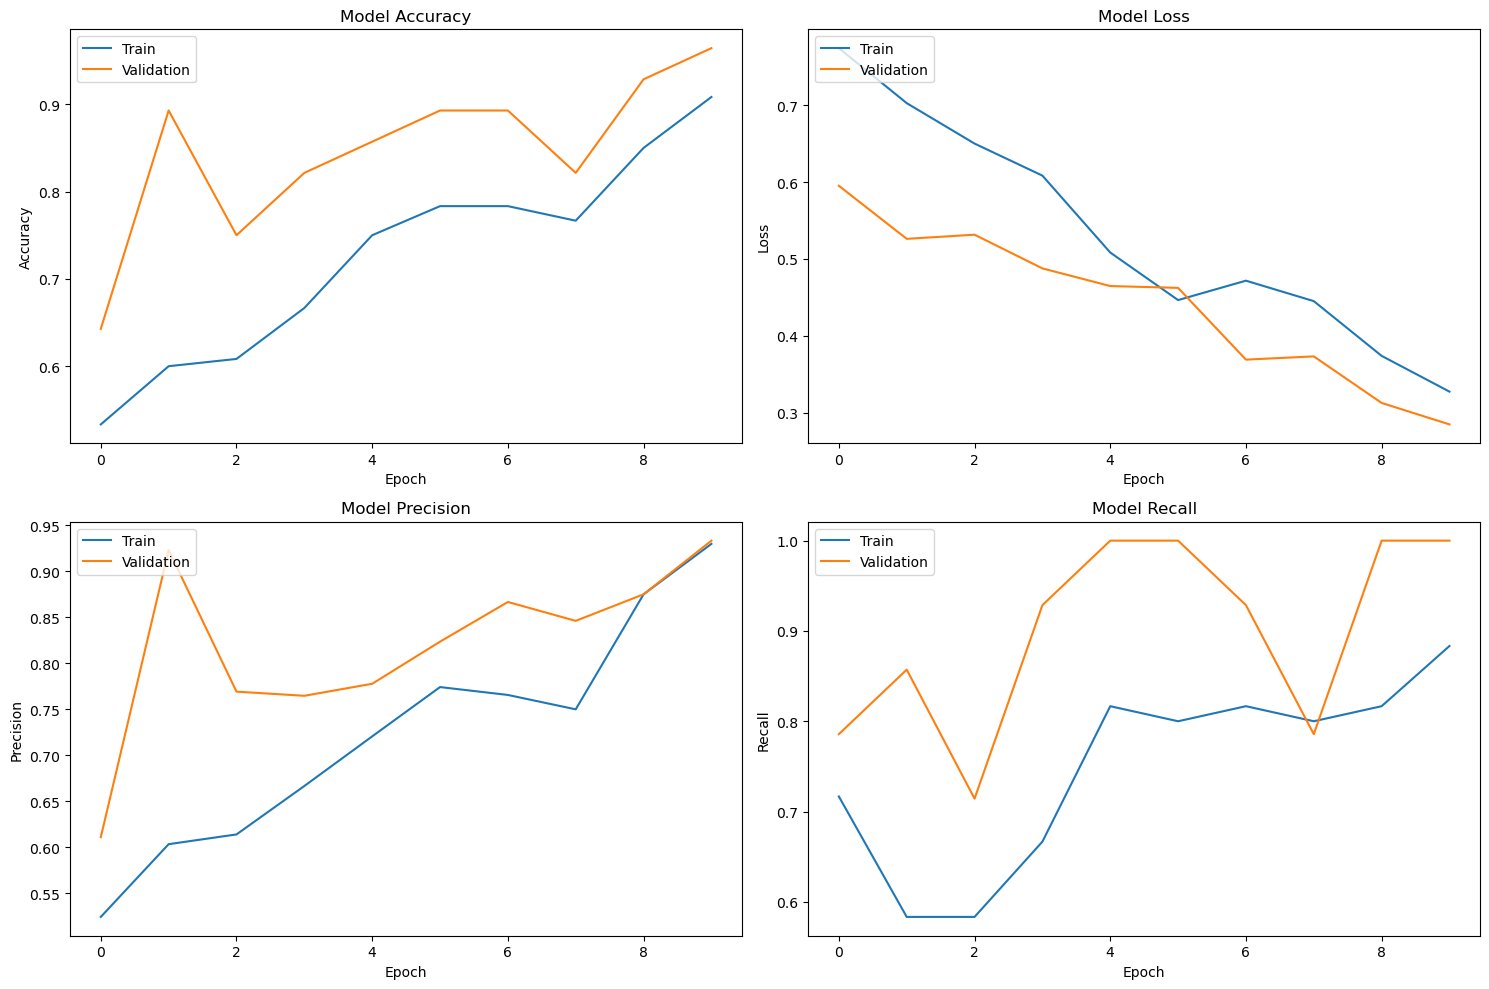

In [11]:
import matplotlib.pyplot as plt

# 학습 히스토리 시각화 (2x2 서브플롯)
plt.figure(figsize=(15, 10))

# 정확도 그래프
plt.subplot(2, 2, 1) # 2행 2열 중 첫 번째
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# 손실 그래프
plt.subplot(2, 2, 2) # 2행 2열 중 두 번째
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# 정밀도 (Precision) 그래프
plt.subplot(2, 2, 3) # 2행 2열 중 세 번째
plt.plot(history.history['precision'])
plt.plot(history.history['val_precision'])
plt.title('Model Precision')
plt.ylabel('Precision')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# 재현율 (Recall) 그래프
plt.subplot(2, 2, 4) # 2행 2열 중 네 번째
plt.plot(history.history['recall'])
plt.plot(history.history['val_recall'])
plt.title('Model Recall')
plt.ylabel('Recall')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout() # 서브플롯 간 간격 자동 조절
plt.show()